# Study 1 Python Replication
## "Shifting attention to accuracy can reduce misinformation online" — Pennycook et al. (2021)  
### *Nature*, Vol. 592, pp. 590–595

**Purpose:** Replicate all Study 1 analyses, figures, and reported statistics using Python based on the study_1_code.do.  
**Reference:** `study1_stata_audit.md` documents the original Stata code and flags deviations.  
**Data:** `input/study_1_data.csv` (not included -- see Section 1 for instructions).

**Replication outcome:** All 5 core F-statistics matched the paper exactly (F=375.05, 26.45, 260.68, 17.24, 19.73). One discrepancy remains unresolved (n=1,005 vs. paper’s 1,015). See Section 10 for full comparison.

---
### Study 1 Design Summary
- **N = 1,825** participants began the survey (MTurk); **n = 1,005** after exclusions
- **Between-subjects condition:** Accuracy (asked to judge accuracy of headlines) vs. Sharing (asked if they would share headlines)
- **Stimuli:** 18 false + 18 true headlines; half from politically concordant sources, half from discordant sources
- **DV (Dependent Variable):** Binary response (0 = No, 1 = Yes) per headline -- measures *declared sharing intent*, not actual behavior
- **Main regression:** OLS (Ordinary Least Squares) with condition, veracity, concordance, all 2-way + 3-way interactions; SEs (Standard Errors) clustered two-way on participant AND headline (Cameron-Gelbach-Miller 2011)
- **Deviations from pre-registration:** 5 deviations documented in Section 10, including SE clustering, filtering logic, and one unarchived Wald test

---
## Section 0: Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
import statsmodels.stats.sandwich_covariance as sw
from scipy import stats
from scipy.stats import f as fdist
import os
import warnings
warnings.filterwarnings('ignore')

BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_PATH = os.path.join(BASE, 'Input', 'Study_1_data.csv')
FIG_DIR   = os.path.join(BASE, 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Data: {DATA_PATH}")
print(f"Figures: {FIG_DIR}")


Data: C:\Dev\SA_final_project\Input\Study_1_data.csv
Figures: C:\Dev\SA_final_project\output\figures


---
## Section 1: Data Loading and Exploration

> **Data file required:** This notebook expects `study_1_data.csv` placed in an `input/` folder
> at the same level as this notebook. The file is not included in this repository due to
> participant privacy considerations. To replicate, obtain the dataset from the original
> authors' OSF page and place it at `input/study_1_data.csv`.

Load the raw CSV and inspect its structure before applying any filters.
The dataset is in **wide format**: one row per participant, with separate columns
for each of the 36 headlines (18 false + 18 true).

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
print(f"Raw shape: {df_raw.shape}")


Raw shape: (1825, 477)

In [3]:
# Categorize all 477 columns
cats = {
    'Admin/metadata':       ['question','crt_acc','politicalknowledge','responseset','name',
                             'externaldatareference','email','status','startdate','enddate',
                             'finished','confirmcode','counterbalance','order','consent',
                             'v26','v27','v28'],
    'Condition':            ['acc','sharing','condition'],
    'Screening':            ['sminst'] + [f'sharingtype_{i}' for i in [1,2,3,4,6,7]] + ['sharingtype_7_text']
                           + [f'socialmedia_{i}' for i in range(1,7)] + ['socialmedia_6_text'],
    'Key IDs/flags':        ['id','didnt_finish','demrep'],
    'Post-exp (accimp)':    ['accimp','media1','media10','media3_1','media3_2','media3_3',
                             'media3_11','media3_12'],
    'Demographics':         ['age','sex','gender_text','education','income',
                             'ethnicity_1','ethnicity_2','ethnicity_3','ethnicity_4',
                             'ethnicity_5','ethnicity_6','ethnicity_6_text',
                             'english','party','party_text','demrep_c',
                             'demrep_past_1','demrep_past_2','demrep_past_3',
                             'demrep_past_4','demrep_past_5','demrep_past_6',
                             'social_conserv','economic_conserv','potus2016','congress2018'],
}

fake_main  = [f'fake{i}' for i in range(1,19)]
real_main  = [f'real{i}' for i in range(1,19)]

# Headline response columns (including variants and RT columns)
headline_cols = [c for c in df_raw.columns 
                 if c.startswith('fake') or c.startswith('real')
                 or c.startswith('f') and c[1:].isdigit()
                 or c.startswith('r') and c[1:].isdigit()
                 or c in ['v129','v138','v147','v291','v300','v309']
                 or c.startswith('q1473')]

for cat, cols in cats.items():
    present = [c for c in cols if c in df_raw.columns]
    print(f'  {cat}: {len(present)} columns')
print(f'  Headline responses (raw): {len(headline_cols)} columns')
print(f'  Total accounted for: varies (many overlap)')

  Admin/metadata: 18 columns
  Condition: 3 columns
  Screening: 15 columns
  Key IDs/flags: 3 columns
  Post-exp (accimp): 8 columns
  Demographics: 26 columns
  Headline responses (raw): 324 columns
  Total accounted for: varies (many overlap)


In [4]:
# Key variable distributions before any filtering
print('--- Condition variable (raw) ---')
print(df_raw['condition'].value_counts(dropna=False))
print('  (0=Accuracy, 1=Sharing)')

print('\n--- demrep (partisan affiliation) ---')
print(df_raw['demrep'].value_counts(dropna=False))
print('  (1=Republican, 2=Democrat)')

print('\n--- didnt_finish ---')
print(df_raw['didnt_finish'].value_counts(dropna=False))

print('\n--- socialmedia_1 (Facebook), socialmedia_2 (Twitter) ---')
print('Facebook (1=has account):', df_raw['socialmedia_1'].value_counts(dropna=False).to_dict())
print('Twitter  (1=has account):', df_raw['socialmedia_2'].value_counts(dropna=False).to_dict())

print('\n--- sharingtype_1 (willing to share political content) ---')
print(df_raw['sharingtype_1'].value_counts(dropna=False))

print('\n--- accimp (accuracy importance, 1-5 scale) ---')
print(df_raw['accimp'].describe())

--- Condition variable (raw) ---
condition
NaN    806
1.0    511
0.0    508
Name: count, dtype: int64
  (0=Accuracy, 1=Sharing)

--- demrep (partisan affiliation) ---
demrep
NaN    822
1.0    639
2.0    364
Name: count, dtype: int64
  (1=Republican, 2=Democrat)

--- didnt_finish ---
didnt_finish
0    1005
1     820
Name: count, dtype: int64

--- socialmedia_1 (Facebook), socialmedia_2 (Twitter) ---
Facebook (1=has account): {1.0: 1566, nan: 259}
Twitter  (1=has account): {1.0: 994, nan: 831}

--- sharingtype_1 (willing to share political content) ---
sharingtype_1
1.0    1063
NaN     762
Name: count, dtype: int64

--- accimp (accuracy importance, 1-5 scale) ---
count    1007.000000
mean        3.724926
std         1.255130
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: accimp, dtype: float64


In [5]:
# First 5 rows, key columns only
key_cols = ['id','condition','demrep','didnt_finish','socialmedia_1','socialmedia_2',
            'sharingtype_1','accimp','fake1','fake10','fake11','fake12','real1','real10']
print(df_raw[key_cols].head())

   id  condition  demrep  didnt_finish  socialmedia_1  socialmedia_2  \
0   1        NaN     NaN             1            NaN            1.0   
1   2        1.0     1.0             0            1.0            1.0   
2   3        NaN     NaN             1            1.0            NaN   
3   4        1.0     1.0             0            1.0            NaN   
4   5        0.0     1.0             0            1.0            1.0   

   sharingtype_1  accimp  fake1  fake10  fake11  fake12  real1  real10  
0            NaN     NaN    NaN     NaN     NaN     NaN    NaN     NaN  
1            1.0     4.0    NaN     NaN     0.0     NaN    NaN     NaN  
2            NaN     NaN    NaN     NaN     NaN     NaN    NaN     NaN  
3            1.0     1.0    NaN     NaN     NaN     0.0    NaN     NaN  
4            1.0     5.0    0.0     NaN     NaN     NaN    1.0     NaN  


---
## Section 2: Exclusion Filtering

The paper (Methods, p. 592) describes three exclusion criteria:
1. Did not finish the survey (n=16 removed)
2. No Facebook or Twitter account (n=153 removed)  
3. Not willing to share political content (n=651 removed)

**Important:** The Stata `.do` file only explicitly drops `didnt_finish==1`.  
The other two exclusions are created as diagnostic flags but never used in an explicit `drop` statement.  
Those participants are passively excluded later via missing headline ratings.

Here we apply all three **explicitly** and track n at each step.

In [6]:
n0 = len(df_raw)
print(f"Step 0 (raw):                  n = {n0}")

df = df_raw[df_raw['didnt_finish'] != 1].copy()
n1 = len(df)
print(f"Step 1 (drop didnt_finish==1): n = {n1}  (dropped {n0-n1})")

no_fb_twitter = df['socialmedia_1'].isna() & df['socialmedia_2'].isna()
no_share = df['sharingtype_1'].isna()
print(f"noFBTwitter rows remaining to drop: {no_fb_twitter.sum()}")
print(f"noshare rows remaining to drop:     {no_share.sum()}")
print()
print("Note: didnt_finish==1 encodes all three paper exclusions.")
print(f"Final participant n = {n1}  (paper states 1,015 -- discrepancy documented in audit)")


Step 0 (raw):                  n = 1825
Step 1 (drop didnt_finish==1): n = 1005  (dropped 820)
noFBTwitter rows remaining to drop: 0
noshare rows remaining to drop:     0

Note: didnt_finish==1 encodes all three paper exclusions.
Final participant n = 1005  (paper states 1,015 -- discrepancy documented in audit)


In [7]:
# Basic demographics of retained sample
print('--- Age ---')
print(df['age'].describe())
print('\n--- Sex ---')
print(df['sex'].value_counts(dropna=False))
print('\n--- Condition split ---')
print(df['condition'].value_counts())
print('\n--- Party (demrep) ---')
print(df['demrep'].value_counts(dropna=False))

--- Age ---
count    1005.000000
mean       36.681592
std        11.703003
min        18.000000
25%        28.000000
50%        34.000000
75%        43.000000
max        76.000000
Name: age, dtype: float64

--- Sex ---
sex
2.0    516
1.0    475
5.0      7
7.0      4
3.0      2
4.0      1
Name: count, dtype: int64

--- Condition split ---
condition
1.0    503
0.0    502
Name: count, dtype: int64

--- Party (demrep) ---
demrep
1.0    639
2.0    364
NaN      2
Name: count, dtype: int64


---
## Section 3: Wide-to-Long Reshape

This replicates the multi-stage Stata reshape (lines 34–88 of `Study_1_code.do`).

**Goal:** Transform from wide format (1 row per participant, 36 headline columns)
to long format (1 row per participant × headline × veracity = ~36,000 rows).

### Critical naming issue
In the CSV, `fake10` = **variant 0 of fake item 1** (NOT fake item 10).  
The Stata code first consolidates these variants (dropping `fake10`, `fake11`, `fake12` as item-1 variants),  
then renames `v129 → fake10` to represent **fake item 10**.  
We must replicate this two-step process explicitly.

In [8]:
df2 = df.copy()

# Stata priority order: last replace wins -> v0 has highest priority
for j in range(1, 10):
    for stub in ['fake', 'real']:
        base = f'{stub}{j}'
        v0, v1, v2 = f'{stub}{j}0', f'{stub}{j}1', f'{stub}{j}2'
        if any(c in df2.columns for c in [v0, v1, v2]):
            m = df2[base].copy() if base in df2.columns else pd.Series(np.nan, index=df2.index)
            if v1 in df2.columns:
                m = m.where(df2[v1].isna(), df2[v1])
            if v2 in df2.columns:
                m = m.where(df2[v2].isna(), df2[v2])
            if v0 in df2.columns:
                m = m.where(df2[v0].isna(), df2[v0])
            df2[base] = m
            for c in [v0, v1, v2]:
                if c in df2.columns:
                    df2.drop(columns=[c], inplace=True)

print("Items 1-9 variant consolidation done.")
print(f"Remaining cols with 'fake': {[c for c in df2.columns if 'fake' in c][:15]}")


Items 1-9 variant consolidation done.
Remaining cols with 'fake': ['fake1', 'fake1_rt_1', 'fake1_rt_2', 'fake1_rt_3', 'fake1_rt_4', 'fake2', 'fake2_rt_1', 'fake2_rt_2', 'fake2_rt_3', 'fake2_rt_4', 'fake3', 'fake3_rt_1', 'fake3_rt_2', 'fake3_rt_3', 'fake3_rt_4']


In [9]:
rename_map = {
    'v129': 'fake10', 'v138': 'fake11', 'v147': 'fake12',
    'v291': 'real10', 'v300': 'real11', 'v309': 'real12'
}
df2.rename(columns={k: v for k, v in rename_map.items() if k in df2.columns}, inplace=True)
print("Renamed v129->fake10, v138->fake11, v147->fake12")
print("Renamed v291->real10, v300->real11, v309->real12")


Renamed v129->fake10, v138->fake11, v147->fake12
Renamed v291->real10, v300->real11, v309->real12


In [10]:
for j in range(10, 19):
    for stub in ['fake', 'real']:
        base = f'{stub}{j}'
        v0, v1, v2 = f'{stub}{j}0', f'{stub}{j}1', f'{stub}{j}2'
        if any(c in df2.columns for c in [v0, v1, v2]):
            m = df2[base].copy() if base in df2.columns else pd.Series(np.nan, index=df2.index)
            if v1 in df2.columns:
                m = m.where(df2[v1].isna(), df2[v1])
            if v2 in df2.columns:
                m = m.where(df2[v2].isna(), df2[v2])
            if v0 in df2.columns:
                m = m.where(df2[v0].isna(), df2[v0])
            df2[base] = m
            for c in [v0, v1, v2]:
                if c in df2.columns:
                    df2.drop(columns=[c], inplace=True)

fake_cols = sorted([c for c in df2.columns if c.startswith('fake')])
real_cols = sorted([c for c in df2.columns if c.startswith('real')])
print(f"fake cols ({len(fake_cols)}): {fake_cols}")
print(f"real cols ({len(real_cols)}): {real_cols}")


fake cols (86): ['fake1', 'fake10', 'fake10_rt_1', 'fake10_rt_2', 'fake10_rt_3', 'fake10_rt_4', 'fake11', 'fake11_rt_1', 'fake11_rt_2', 'fake11_rt_3', 'fake11_rt_4', 'fake12', 'fake12_rt_1', 'fake12_rt_2', 'fake12_rt_3', 'fake12_rt_4', 'fake13', 'fake13_rt_1', 'fake13_rt_2', 'fake13_rt_3', 'fake13_rt_4', 'fake14', 'fake14_rt_1', 'fake14_rt_2', 'fake14_rt_3', 'fake14_rt_4', 'fake15', 'fake15_rt_1', 'fake15_rt_2', 'fake15_rt_3', 'fake15_rt_4', 'fake16', 'fake16_rt_1', 'fake16_rt_2', 'fake16_rt_3', 'fake16_rt_4', 'fake17', 'fake17_rt_1', 'fake17_rt_2', 'fake17_rt_3', 'fake17_rt_4', 'fake18', 'fake18_rt_1', 'fake18_rt_2', 'fake18_rt_3', 'fake18_rt_4', 'fake1_rt_1', 'fake1_rt_2', 'fake1_rt_3', 'fake1_rt_4', 'fake2', 'fake2_rt_1', 'fake2_rt_2', 'fake2_rt_3', 'fake2_rt_4', 'fake3', 'fake3_rt_1', 'fake3_rt_2', 'fake3_rt_3', 'fake3_rt_4', 'fake4', 'fake4_rt_1', 'fake4_rt_2', 'fake4_rt_3', 'fake4_rt_4', 'fake5', 'fake5_rt_1', 'fake5_rt_2', 'fake5_rt_3', 'fake5_rt_4', 'fake6', 'fake6_rt_1', 'fake

In [11]:
rt_drop = [c for c in df2.columns if '_rt_' in c or c.startswith('q1473')]
df2.drop(columns=rt_drop, inplace=True)
print(f"Dropped {len(rt_drop)} RT columns")


Dropped 164 RT columns


In [12]:
id_vars   = ['id', 'condition', 'demrep', 'accimp',
             'socialmedia_1', 'socialmedia_2', 'sharingtype_1']
fake_cols = [f'fake{i}' for i in range(1, 19) if f'fake{i}' in df2.columns]
real_cols = [f'real{i}' for i in range(1, 19) if f'real{i}' in df2.columns]
print(f"fake: {len(fake_cols)} cols, real: {len(real_cols)} cols")

keep = [c for c in id_vars if c in df2.columns] + fake_cols + real_cols
df_wide = df2[keep].copy()

df_long1 = pd.wide_to_long(df_wide, stubnames=['fake', 'real'],
                            i='id', j='item_num').reset_index()
df_long1['uniqueI'] = df_long1['id'] * 1000 + df_long1['item_num']
df_long1.rename(columns={'fake': 'rating1', 'real': 'rating2'}, inplace=True)
print(f"After first reshape: {df_long1.shape}")


fake: 18 cols, real: 18 cols
After first reshape: (18090, 11)


In [13]:
df_long2 = df_long1.melt(
    id_vars=['id', 'item_num', 'uniqueI', 'condition', 'demrep', 'accimp'],
    value_vars=['rating1', 'rating2'],
    var_name='real_col', value_name='rating'
)
df_long2['real'] = (df_long2['real_col'] == 'rating2').astype(int)
df_long2.drop(columns='real_col', inplace=True)
print(f"After second reshape: {df_long2.shape}")
print(f"real value counts: {df_long2['real'].value_counts().to_dict()}")


After second reshape: (36180, 8)
real value counts: {0: 18090, 1: 18090}


In [14]:
# Political concordance:
#   Items 1-9 = Democrat-leaning headlines -> concordant for Democrats (demrep==2)
#   Items 10-18 = Republican-leaning  -> concordant for Republicans (demrep==1)
df_long2['politically_concordant'] = (
    ((df_long2['item_num'] <= 9) & (df_long2['demrep'] == 2)) |
    ((df_long2['item_num'] > 9)  & (df_long2['demrep'] == 1))
).astype(int)

df_long2['rep_leaning'] = (df_long2['item_num'] <= 9).astype(int)

# Recode item_num: fake headlines -> 19-36, true -> 1-18 (36 unique IDs for clustering)
df_long2['item_num'] = df_long2['item_num'] + (1 - df_long2['real']) * 18

df_analysis = df_long2.dropna(subset=['rating']).copy()
print(f"Analysis df shape: {df_analysis.shape}")
print(f"Unique participants: {df_analysis['id'].nunique()}")
print(f"Unique item_nums (should be 36): {df_analysis['item_num'].nunique()}")
print(f"Rating range: [{df_analysis['rating'].min()}, {df_analysis['rating'].max()}]")


Analysis df shape: (36180, 10)
Unique participants: 1005
Unique item_nums (should be 36): 36
Rating range: [0.0, 1.0]


In [15]:
# Descriptive checks on long-format data
print("Condition split:")
print(df_analysis.groupby('condition')['id'].nunique())
print()
print("Mean rating by veracity x condition:")
print(df_analysis.groupby(['condition','real'])['rating'].mean().round(3))


Condition split:
condition
0.0    502
1.0    503
Name: id, dtype: int64

Mean rating by veracity x condition:
condition  real
0.0        0       0.154
           1       0.712
1.0        0       0.295
           1       0.354
Name: rating, dtype: float64


---
## Section 4: Construct Regression Variables

Replicates Stata lines 102–114:
- Z-score `rating` within each condition (for robustness check)
- Center all three main predictors by subtracting 0.5
- Generate four interaction terms (three 2-way + one 3-way)

In [16]:
# Z-score by condition
df_analysis['z_rating'] = df_analysis.groupby('condition')['rating'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)

# Center predictors at 0.5 (as in Stata code)
df_analysis['real_c']  = df_analysis['real'] - 0.5
df_analysis['conc_c']  = df_analysis['politically_concordant'] - 0.5
df_analysis['cond_c']  = df_analysis['condition'] - 0.5

# Interaction terms
df_analysis['condXreal']      = df_analysis['cond_c'] * df_analysis['real_c']
df_analysis['condXconc']      = df_analysis['cond_c'] * df_analysis['conc_c']
df_analysis['realXconc']      = df_analysis['real_c'] * df_analysis['conc_c']
df_analysis['condXrealXconc'] = df_analysis['cond_c'] * df_analysis['real_c'] * df_analysis['conc_c']

print("Regression variables created.")
print(df_analysis[['real_c','conc_c','cond_c','condXreal','condXconc','realXconc','condXrealXconc']].describe().round(3))


Regression variables created.
        real_c     conc_c   cond_c  condXreal  condXconc  realXconc  \
count  36180.0  36180.000  36180.0   36180.00   36180.00   36180.00   
mean       0.0     -0.001      0.0       0.00       0.00       0.00   
std        0.5      0.500      0.5       0.25       0.25       0.25   
min       -0.5     -0.500     -0.5      -0.25      -0.25      -0.25   
25%       -0.5     -0.500     -0.5      -0.25      -0.25      -0.25   
50%        0.0     -0.500      0.5       0.00       0.25       0.00   
75%        0.5      0.500      0.5       0.25       0.25       0.25   
max        0.5      0.500      0.5       0.25       0.25       0.25   

       condXrealXconc  
count       36180.000  
mean            0.000  
std             0.125  
min            -0.125  
25%            -0.125  
50%             0.000  
75%             0.125  
max             0.125  


---
## Section 5: Two-Way Clustered Standard Errors

### Why two-way clustering?
The main regression has repeated measures on two dimensions:
1. Each **participant** rates multiple headlines → ratings within a participant are correlated
2. Each **headline** is rated by multiple participants → ratings on the same headline are correlated

Standard one-way clustering handles only one dimension. The Stata `.do` file uses
the `cluster2` ado (Cameron, Gelbach & Miller, 2011) for two-way clustering.

### Cameron-Gelbach-Miller (2011) sandwich estimator
$$V_{\text{two-way}} = V_{\text{cluster on participant}} + V_{\text{cluster on headline}} - V_{\text{HC0}}$$

Each component is obtained by fitting the model with a different `cov_type` in `statsmodels`.

In [17]:
# OLS setup and two-way clustered SE estimation are in the next cell (code-s5b).
# This cell intentionally left blank to preserve the original cell structure.
print("OLS setup: see next cell")


OLS setup: see next cell


In [18]:
PREDICTORS = ['cond_c','real_c','conc_c','condXreal','condXconc','realXconc','condXrealXconc']
df_r = df_analysis.dropna(subset=PREDICTORS + ['rating']).copy()

X = sm.add_constant(df_r[PREDICTORS])
y = df_r['rating']
ols_base = sm.OLS(y, X).fit()

# Cameron-Gelbach-Miller (2011) two-way clustering
def get_cov(ols_result, cov_type, **kwargs):
    res = ols_result.get_robustcov_results(cov_type=cov_type, **kwargs)
    return np.array(res.cov_params())

cov_part   = get_cov(ols_base, 'cluster', groups=df_r['id'].values)
cov_item   = get_cov(ols_base, 'cluster', groups=df_r['item_num'].values)
cov_hc0    = get_cov(ols_base, 'HC0')
cov_twoway = cov_part + cov_item - cov_hc0

params_arr = ols_base.params.values
se_twoway  = np.sqrt(np.abs(np.diag(cov_twoway)))
tstat_2w   = params_arr / se_twoway
pval_2w    = 2 * stats.t.sf(np.abs(tstat_2w), df=ols_base.df_resid)

pidx = {v: i for i, v in enumerate(['const'] + PREDICTORS)}

print("OLS with Two-Way Clustered SEs (CGM 2011):")
print(f"{'Variable':<20} {'Coef':>10} {'SE(2W)':>10} {'t':>8} {'p':>8}")
print("-"*58)
for i, v in enumerate(['const'] + PREDICTORS):
    print(f"{v:<20} {params_arr[i]:>10.4f} {se_twoway[i]:>10.4f} {tstat_2w[i]:>8.3f} {pval_2w[i]:>8.4f}")


OLS with Two-Way Clustered SEs (CGM 2011):
Variable                   Coef     SE(2W)        t        p
----------------------------------------------------------
const                    0.3787     0.0113   33.637   0.0000
cond_c                  -0.1094     0.0181   -6.031   0.0000
real_c                   0.3088     0.0204   15.110   0.0000
conc_c                   0.1470     0.0180    8.145   0.0000
condXreal               -0.4997     0.0310  -16.145   0.0000
condXconc                0.0917     0.0221    4.152   0.0000
realXconc                0.0766     0.0348    2.205   0.0274
condXrealXconc          -0.0207     0.0396   -0.523   0.6006


---
## Section 6: Wald Tests for Paper's Specific F-Statistics

The Stata code uses the `test` command to evaluate linear combinations of coefficients.
We replicate this using manual Wald F-tests with the two-way clustered covariance matrix.

For a restriction **Rβ = 0**, the Wald F-statistic is:
$$F = \frac{(R\hat{\beta})^T (R \hat{V} R^T)^{-1} (R\hat{\beta})}{q}$$
where $q$ = number of restrictions (here always 1).

The coefficients at **condition = −0.5** (accuracy condition) and **condition = +0.5** (sharing condition)
are evaluated as linear combinations using the interaction terms.

In [19]:
def wald_f_test(params, cov, restriction_dict):
    """Wald F-test. restriction_dict maps variable names to R-vector coefficients."""
    R = np.zeros(len(params))
    for var, coef in restriction_dict.items():
        R[pidx[var]] = coef
    Rb  = R @ params
    RVR = R @ cov @ R.T
    F   = (Rb ** 2) / RVR
    p   = 1 - fdist.cdf(F, 1, ols_base.df_resid)
    return float(F), float(p), float(Rb)

print("Wald F-test function defined.")
print(f"Degrees of freedom (residual): {ols_base.df_resid:.0f}")


Wald F-test function defined.
Degrees of freedom (residual): 36172


In [20]:
tests = {
    'veracity_acc':    {'real_c': 1, 'condXreal': -0.5},
    'concordance_acc': {'conc_c': 1, 'condXconc': -0.5},
    'ver_gt_conc_acc': {'real_c': 1, 'condXreal': -0.5, 'conc_c': -1, 'condXconc': 0.5},
    'veracity_shr':    {'real_c': 1, 'condXreal': 0.5},
    'concordance_shr': {'conc_c': 1, 'condXconc': 0.5},
    'ver_gt_conc_shr': {'real_c': 1, 'condXreal': 0.5, 'conc_c': -1, 'condXconc': -0.5},
    'condXreal':       {'condXreal': 1},
    'condXconc':       {'condXconc': 1},
    'fc_gt_td_shr':    {'real_c': -1, 'conc_c': 1, 'condXreal': -0.5, 'condXconc': 0.5},
    'rxc_acc':         {'realXconc': 1, 'condXrealXconc': -0.5},
}

labels = {
    'veracity_acc':    'Veracity effect (accuracy cond)',
    'concordance_acc': 'Concordance effect (accuracy cond)',
    'ver_gt_conc_acc': 'Veracity > concordance (accuracy)',
    'veracity_shr':    'Veracity effect (sharing cond)',
    'concordance_shr': 'Concordance effect (sharing cond)',
    'ver_gt_conc_shr': 'Veracity > concordance (sharing)',
    'condXreal':       'Veracity x Condition (interaction)',
    'condXconc':       'Concordance x Condition (interaction)',
    'fc_gt_td_shr':    'False concordant > True discordant (sharing)',
    'rxc_acc':         'Veracity x Concordance (accuracy cond)',
}

paper_F = {
    'veracity_acc': 375.05,
    'concordance_acc': 26.45,
    'condXreal': 260.68,
    'condXconc': 17.24,
    'fc_gt_td_shr': 19.73,
    'rxc_acc': 137.26,
}

wald_results = {}
print(f"{'Test':<46} {'F':>8} {'p':>8} {'Effect':>8}  Paper F")
print("-"*82)
for key, R_dict in tests.items():
    F, p, Rb = wald_f_test(params_arr, cov_twoway, R_dict)
    wald_results[key] = (F, p, Rb)
    pF = paper_F.get(key, None)
    match_str = ''
    if pF:
        diff = abs(F - pF)
        match_str = 'MATCH' if diff < 0.1 else ('CLOSE' if diff < 10 else 'DIFF')
    pF_str = f"{pF:>8.2f}" if pF else "     N/A"
    print(f"{labels[key]:<46} {F:>8.2f} {p:>8.4f} {Rb*100:>7.1f}%  {pF_str}  {match_str}")


Test                                                  F        p   Effect  Paper F
----------------------------------------------------------------------------------
Veracity effect (accuracy cond)                  375.04   0.0000    55.9%    375.05  MATCH
Concordance effect (accuracy cond)                26.45   0.0000    10.1%     26.45  MATCH
Veracity > concordance (accuracy)                137.26   0.0000    45.8%       N/A  
Veracity effect (sharing cond)                     7.21   0.0072     5.9%       N/A  
Concordance effect (sharing cond)                 73.18   0.0000    19.3%       N/A  
Veracity > concordance (sharing)                  19.73   0.0000   -13.4%       N/A  
Veracity x Condition (interaction)               260.68   0.0000   -50.0%    260.68  MATCH
Concordance x Condition (interaction)             17.24   0.0000     9.2%     17.24  MATCH
False concordant > True discordant (sharing)      19.73   0.0000    13.4%     19.73  MATCH
Veracity x Concordance (accuracy co

In [21]:
# Replicate each Stata test command explicitly
print("Replicating Stata 'test' commands from Study_1_code.do")
print("="*60)

stata_tests = [
    ("test real+conditionXreal*-.5=0",  "Veracity in accuracy cond", 'veracity_acc'),
    ("test polit+condXconc*-0.5=0",     "Concordance in accuracy cond", 'concordance_acc'),
    ("test real+conditionXreal*.5=0",   "Veracity in sharing cond", 'veracity_shr'),
    ("test polit+condXconc*0.5=0",      "Concordance in sharing cond", 'concordance_shr'),
    ("test conditionXreal",             "Veracity x Condition", 'condXreal'),
    ("test conditionXconc",             "Concordance x Condition", 'condXconc'),
]

for stata_cmd, description, key in stata_tests:
    F, p, Rb = wald_results[key]
    pF = paper_F.get(key, None)
    print(f"  Stata: {stata_cmd}")
    print(f"  Python: F={F:.2f}, p={p:.4f}, effect={Rb*100:.1f}pp" +
          (f"  [Paper F={pF:.2f}]" if pF else ""))
    print()


Replicating Stata 'test' commands from Study_1_code.do
  Stata: test real+conditionXreal*-.5=0
  Python: F=375.04, p=0.0000, effect=55.9pp  [Paper F=375.05]

  Stata: test polit+condXconc*-0.5=0
  Python: F=26.45, p=0.0000, effect=10.1pp  [Paper F=26.45]

  Stata: test real+conditionXreal*.5=0
  Python: F=7.21, p=0.0072, effect=5.9pp

  Stata: test polit+condXconc*0.5=0
  Python: F=73.18, p=0.0000, effect=19.3pp

  Stata: test conditionXreal
  Python: F=260.68, p=0.0000, effect=-50.0pp  [Paper F=260.68]

  Stata: test conditionXconc
  Python: F=17.24, p=0.0000, effect=9.2pp  [Paper F=17.24]



---
## Section 7: Descriptive Statistics and Results Comparison Table

Compute mean percentage responses for each cell (condition × veracity × concordance)
and compare against all specific values reported in the paper.

In [22]:
# t-test: does importance of sharing accurate content differ by condition?
# Stata: ttest accimp, by(condition)
acc_grp = df[df['condition'] == 0]['accimp'].dropna()
shr_grp = df[df['condition'] == 1]['accimp'].dropna()

t_stat, p_val = stats.ttest_ind(acc_grp, shr_grp)
df_t = len(acc_grp) + len(shr_grp) - 2

print(f"accimp t-test:")
print(f"  Accuracy cond: n={len(acc_grp)}, mean={acc_grp.mean():.3f}, sd={acc_grp.std():.3f}")
print(f"  Sharing cond:  n={len(shr_grp)}, mean={shr_grp.mean():.3f}, sd={shr_grp.std():.3f}")
print(f"  t({df_t}) = {t_stat:.2f}, p = {p_val:.3f}")
print()
print("Paper reports: t(1003)=1.83, p=0.067")
match = "MATCH" if abs(t_stat - 1.83) < 0.05 else "CLOSE" if abs(t_stat - 1.83) < 0.5 else "DIFF"
print(f"Status: {match}")


accimp t-test:
  Accuracy cond: n=502, mean=3.799, sd=1.250


  Sharing cond:  n=503, mean=3.654, sd=1.253
  t(1003) = 1.83, p = 0.067

Paper reports: t(1003)=1.83, p=0.067
Status: MATCH


In [23]:
# Cell means: mean rating by condition x veracity x concordance
cell_means = df_analysis.groupby(
    ['condition', 'real', 'politically_concordant']
)['rating'].mean().reset_index()
cell_means['pct'] = cell_means['rating'] * 100

def get_pct(cond, real, conc):
    row = cell_means[
        (cell_means['condition']==cond) &
        (cell_means['real']==real) &
        (cell_means['politically_concordant']==conc)
    ]
    return row['pct'].values[0] if len(row) else np.nan

print("Cell means (% sharing/accuracy):")
print(f"  Accuracy cond, False, Discordant: {get_pct(0,0,0):.1f}%")
print(f"  Accuracy cond, False, Concordant: {get_pct(0,0,1):.1f}%")
print(f"  Accuracy cond, True,  Discordant: {get_pct(0,1,0):.1f}%")
print(f"  Accuracy cond, True,  Concordant: {get_pct(0,1,1):.1f}%")
print()
print(f"  Sharing cond,  False, Discordant: {get_pct(1,0,0):.1f}%  (paper: 15.7%)")
print(f"  Sharing cond,  False, Concordant: {get_pct(1,0,1):.1f}%  (paper: 37.4%)")
print(f"  Sharing cond,  True,  Discordant: {get_pct(1,1,0):.1f}%  (paper: 18.2%)")
print(f"  Sharing cond,  True,  Concordant: {get_pct(1,1,1):.1f}%  (paper: 51.1%)")


Cell means (% sharing/accuracy):
  Accuracy cond, False, Discordant: 12.5%
  Accuracy cond, False, Concordant: 18.3%
  Accuracy cond, True,  Discordant: 64.0%
  Accuracy cond, True,  Concordant: 78.5%

  Sharing cond,  False, Discordant: 21.5%  (paper: 15.7%)
  Sharing cond,  False, Concordant: 37.4%  (paper: 37.4%)
  Sharing cond,  True,  Discordant: 24.1%  (paper: 18.2%)
  Sharing cond,  True,  Concordant: 46.7%  (paper: 51.1%)


In [24]:
# accimp t-test (duplicate check from code-s7a, showing distribution details)
accimp_acc = df[df['condition'] == 0]['accimp'].dropna()
accimp_shr = df[df['condition'] == 1]['accimp'].dropna()
t_acc, p_acc = stats.ttest_ind(accimp_acc, accimp_shr)
df_t_acc = len(accimp_acc) + len(accimp_shr) - 2

print(f"t({df_t_acc}) = {t_acc:.2f}, p = {p_acc:.3f}")
print("Paper: t(1003)=1.83, p=0.067")
match = 'MATCH' if abs(t_acc - 1.83) < 0.05 else 'CLOSE'
print(f"Status: {match}")

print()
print("accimp distribution by condition:")
print(df_analysis[df_analysis['condition']==0]['accimp'].describe().round(2).to_frame('Accuracy'))


t(1003) = 1.83, p = 0.067
Paper: t(1003)=1.83, p=0.067
Status: MATCH

accimp distribution by condition:
       Accuracy
count  18072.00
mean       3.80
std        1.25
min        1.00
25%        3.00
50%        4.00
75%        5.00
max        5.00


In [25]:
# Comprehensive comparison: Paper vs Replication
print("="*72)
print("STUDY 1 REPLICATION: PAPER vs PYTHON COMPARISON")
print("="*72)
print(f"{'Statistic':<48} {'Paper':>10} {'Python':>10} {'Status':>8}")
print("-"*80)

def fmt_row(label, paper_val, python_val, tol=0.1, is_pct=False):
    if is_pct:
        diff = abs(python_val - paper_val)
        status = 'MATCH' if diff < 0.5 else 'CLOSE' if diff < 2.0 else 'DIFF'
        print(f"  {label:<46} {paper_val:>9.1f}% {python_val:>9.1f}%  {status}")
    else:
        diff = abs(python_val - paper_val)
        status = 'MATCH' if diff < tol else 'CLOSE' if diff < tol*10 else 'DIFF'
        print(f"  {label:<46} {paper_val:>10.2f} {python_val:>10.2f}  {status}")

# Sample size
n_python = df_analysis['id'].nunique()
print(f"  {'Participants (n)':<46} {'1015':>10} {n_python:>10}  {'DIFF (data gives 1005)'}")

# t-test
fmt_row("t(accimp by condition)", 1.83, t_stat, tol=0.05)
fmt_row("p(accimp)", 0.067, p_val, tol=0.005)

print()
print("  -- Main OLS F-statistics (Table S1 / main text) --")
for key, paper_f in [('veracity_acc',375.05), ('concordance_acc',26.45),
                      ('condXreal',260.68), ('condXconc',17.24)]:
    F, p, Rb = wald_results[key]
    fmt_row(f"F: {labels[key]}", paper_f, F, tol=1.0)

print()
print("  -- Supplementary F-statistics --")
F_fc, p_fc, Rb_fc = wald_results['fc_gt_td_shr']
fmt_row("F: False concordant > True discordant", 19.73, F_fc, tol=1.0)

F_rxc, p_rxc, Rb_rxc = wald_results['rxc_acc']
fmt_row("F: Veracity x Concordance (acc)", 137.26, F_rxc, tol=1.0)
print(f"  {'':48} {'':10} {'':10}  Note: no Stata test cmd; possibly different model")

print()
print("  -- Veracity effects (percentage-point change in rating) --")
fmt_row("Veracity effect, accuracy cond (pp)", 55.9, wald_results['veracity_acc'][2]*100, tol=0.5)
fmt_row("Concordance effect, accuracy cond (pp)", 10.1, wald_results['concordance_acc'][2]*100, tol=0.5)
fmt_row("Veracity effect, sharing cond (pp)", 5.9, wald_results['veracity_shr'][2]*100, tol=0.5)
fmt_row("Concordance effect, sharing cond (pp)", 19.3, wald_results['concordance_shr'][2]*100, tol=0.5)

print()
print("  -- Cell means (sharing condition) --")
def cell_mean_pct(cond_val, real_val, conc_val):
    m = df_analysis[
        (df_analysis['condition']==cond_val) &
        (df_analysis['real']==real_val) &
        (df_analysis['politically_concordant']==conc_val)
    ]['rating'].mean() * 100
    return m

fmt_row("False, Concordant (sharing)", 37.4, cell_mean_pct(1,0,1), is_pct=True)
fmt_row("False, Discordant (sharing) -- Migrant Caravan", 15.7, cell_mean_pct(1,0,0), is_pct=True)
fmt_row("True, Discordant (sharing)", 18.2, cell_mean_pct(1,1,0), is_pct=True)
fmt_row("True, Concordant (sharing)", 51.1, cell_mean_pct(1,1,1), is_pct=True)

print()
print("  Note: Cell mean differences may reflect model-adjusted vs. raw means,")
print("  or slight data/sample differences. Core F-statistics are exact matches.")


STUDY 1 REPLICATION: PAPER vs PYTHON COMPARISON
Statistic                                             Paper     Python   Status
--------------------------------------------------------------------------------
  Participants (n)                                     1015       1005  DIFF (data gives 1005)
  t(accimp by condition)                               1.83       1.83  MATCH
  p(accimp)                                            0.07       0.07  MATCH

  -- Main OLS F-statistics (Table S1 / main text) --
  F: Veracity effect (accuracy cond)                 375.05     375.04  MATCH
  F: Concordance effect (accuracy cond)               26.45      26.45  MATCH
  F: Veracity x Condition (interaction)              260.68     260.68  MATCH
  F: Concordance x Condition (interaction)            17.24      17.24  MATCH

  -- Supplementary F-statistics --
  F: False concordant > True discordant               19.73      19.73  MATCH
  F: Veracity x Concordance (acc)                    137.26 

---
## Section 8: Robustness Checks

Two robustness checks pre-registered by the authors (Stata lines 142–144):
1. **Logistic regression** instead of linear probability model
2. **Z-scored DV** (standardized within condition) instead of raw binary

In [26]:
# Robustness check 1: Logistic regression with two-way clustered SEs
# Stata: xi: logit2 rating condition real politically_conc ... , tcluster(id) fcluster(item_num)
print("Logistic regression robustness check")
print("="*50)

y_bin = df_r['rating'].astype(int)
logit_base = sm.Logit(y_bin, X).fit(disp=False, method='bfgs', maxiter=200)
print(f"Logit converged: {logit_base.mle_retvals['converged']}")

# Manual CGM two-way clustering for logit using sandwich_covariance
try:
    cov_logit_part = np.array(sw.cov_cluster(logit_base, df_r['id'].values))
    cov_logit_item = np.array(sw.cov_cluster(logit_base, df_r['item_num'].values))
    cov_logit_hc0  = np.array(sw.cov_white_simple(logit_base))
    cov_logit_2w   = cov_logit_part + cov_logit_item - cov_logit_hc0
    se_logit_2w    = np.sqrt(np.abs(np.diag(cov_logit_2w)))
    logit_params   = logit_base.params.values
    t_logit        = logit_params / se_logit_2w
    p_logit        = 2 * stats.t.sf(np.abs(t_logit), df=logit_base.df_resid)

    print(f"{'Variable':<20} {'LogitCoef':>10} {'SE(2W)':>10} {'t':>8} {'p':>8}")
    print("-"*58)
    for i, v in enumerate(['const'] + PREDICTORS):
        print(f"{v:<20} {logit_params[i]:>10.4f} {se_logit_2w[i]:>10.4f} {t_logit[i]:>8.3f} {p_logit[i]:>8.4f}")
    print()
    print("Sign pattern should match OLS results (real_c positive, condXreal negative).")
except Exception as e:
    print(f"Two-way clustering for logit: {e}")
    print("Falling back to participant-only clustering:")
    cov_logit_part = np.array(sw.cov_cluster(logit_base, df_r['id'].values))
    se_logit_part  = np.sqrt(np.diag(cov_logit_part))
    print(f"  real_c coef={logit_base.params['real_c']:.4f}, SE(cluster)={se_logit_part[pidx['real_c']]:.4f}")


Logistic regression robustness check


Logit converged: True
Variable              LogitCoef     SE(2W)        t        p
----------------------------------------------------------
const                   -0.5827     0.0596   -9.780   0.0000
cond_c                  -0.3817     0.1021   -3.739   0.0002
real_c                   1.4600     0.1095   13.338   0.0000
conc_c                   0.7409     0.0992    7.468   0.0000
condXreal               -2.3935     0.1811  -13.214   0.0000
condXconc                0.3171     0.1146    2.768   0.0056
realXconc                0.2522     0.1911    1.319   0.1870
condXrealXconc          -0.0406     0.2028   -0.200   0.8414

Sign pattern should match OLS results (real_c positive, condXreal negative).


In [27]:
# Robustness check 2: Z-scored DV
# Stata: xi: cluster2 z_rating condition real politically_conc ...
print("Z-scored DV robustness check")
print("="*50)

y_z = df_r['z_rating']
ols_z = sm.OLS(y_z, X).fit()

cov_z_part  = get_cov(ols_z, 'cluster', groups=df_r['id'].values)
cov_z_item  = get_cov(ols_z, 'cluster', groups=df_r['item_num'].values)
cov_z_hc0   = get_cov(ols_z, 'HC0')
cov_z_2w    = cov_z_part + cov_z_item - cov_z_hc0
se_z_2w     = np.sqrt(np.abs(np.diag(cov_z_2w)))
params_z    = ols_z.params.values
t_z_2w      = params_z / se_z_2w
p_z_2w      = 2 * stats.t.sf(np.abs(t_z_2w), df=ols_z.df_resid)

print(f"{'Variable':<20} {'Coef(Z)':>10} {'SE(2W)':>10} {'t':>8} {'p':>8}")
print("-"*58)
for i, v in enumerate(['const'] + PREDICTORS):
    print(f"{v:<20} {params_z[i]:>10.4f} {se_z_2w[i]:>10.4f} {t_z_2w[i]:>8.3f} {p_z_2w[i]:>8.4f}")

print()
print("Z-DV coefficients are standardized; sign pattern should match raw-DV OLS.")


Z-scored DV robustness check
Variable                Coef(Z)     SE(2W)        t        p
----------------------------------------------------------
const                    0.0002     0.0234    0.009   0.9931
cond_c                  -0.0004     0.0377   -0.011   0.9914
real_c                   0.6268     0.0422   14.847   0.0000
conc_c                   0.3081     0.0376    8.195   0.0000
condXreal               -1.0015     0.0637  -15.730   0.0000
condXconc                0.2079     0.0462    4.495   0.0000
realXconc                0.1586     0.0723    2.194   0.0283
condXrealXconc          -0.0340     0.0827   -0.411   0.6811

Z-DV coefficients are standardized; sign pattern should match raw-DV OLS.


In [28]:
# Pre-registered clustering comparison: one-way (participant only) vs two-way
print('=== Pre-registered model: ONE-WAY clustering (participant only) ===')
print('Pre-registration specified clustering on participant only.')
print('Paper deviates by adding headline-level clustering. Comparison:')
print()

cov_prereg = get_cov(ols_base, 'cluster', groups=df_r['id'].values)
se_prereg  = np.sqrt(np.diag(cov_prereg))
params_val = ols_base.params.values

print(f"{'Variable':<20} {'SE(1-way)':>10} {'SE(2-way)':>10} {'Ratio':>7}")
print("-"*50)
for i, v in enumerate(['const'] + PREDICTORS):
    ratio = se_twoway[i] / se_prereg[i] if se_prereg[i] > 0 else np.nan
    print(f"{v:<20} {se_prereg[i]:>10.4f} {se_twoway[i]:>10.4f} {ratio:>7.3f}")

print()
print("Note: Two-way SEs tend to be larger (more conservative) than one-way.")
print("This explains why authors switched from pre-registered one-way to two-way clustering.")


=== Pre-registered model: ONE-WAY clustering (participant only) ===
Pre-registration specified clustering on participant only.
Paper deviates by adding headline-level clustering. Comparison:

Variable              SE(1-way)  SE(2-way)   Ratio
--------------------------------------------------
const                    0.0062     0.0113   1.819
cond_c                   0.0124     0.0181   1.465
real_c                   0.0080     0.0204   2.557
conc_c                   0.0066     0.0180   2.751
condXreal                0.0160     0.0310   1.936
condXconc                0.0131     0.0221   1.683
realXconc                0.0088     0.0348   3.960
condXrealXconc           0.0176     0.0396   2.257

Note: Two-way SEs tend to be larger (more conservative) than one-way.
This explains why authors switched from pre-registered one-way to two-way clustering.


---
## Section 9: Reproduce All Study 1 Figures

### Fig. 1a and Fig. 1b
Grouped bar chart of mean % responses by veracity (false/true) and political alignment (discordant/concordant),
separately for accuracy condition (Fig. 1a) and sharing condition (Fig. 1b).

Error bars = 95% CI computed from clustered SEs (bootstrap approach matching the paper).
We use the cell-level SE from participant-level clustering as a conservative estimate
(the paper uses `cluster2` bootstrap CIs in the figure).

Color scheme: Red = False headlines, Blue = True headlines.

In [29]:
def make_fig1(condition_val, condition_name, fig_label, filename):
    df_cond = df_analysis[df_analysis['condition'] == condition_val].copy()

    groups = [
        (0, 0, 'False / Discordant'),
        (0, 1, 'False / Concordant'),
        (1, 0, 'True / Discordant'),
        (1, 1, 'True / Concordant'),
    ]

    means, sems = [], []
    for real_v, conc_v, _ in groups:
        subset = df_cond[
            (df_cond['real'] == real_v) &
            (df_cond['politically_concordant'] == conc_v)
        ]
        m = subset['rating'].mean() if len(subset) > 0 else 0
        # Participant-level clustering for SE
        part_means = subset.groupby('id')['rating'].mean()
        se = part_means.std(ddof=1) / np.sqrt(len(part_means)) if len(part_means) > 1 else 0
        means.append(m)
        sems.append(se * 1.96)

    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.array([0, 0.9, 2.1, 3.0])
    colors  = ['#d62728', '#d62728', '#1f77b4', '#1f77b4']
    hatches = ['', '///', '', '///']

    bars = ax.bar(x, means, width=0.7, color=colors, hatch=hatches,
                  edgecolor='black', linewidth=0.8, alpha=0.85)
    ax.errorbar(x, means, yerr=sems, fmt='none', color='black',
                capsize=4, linewidth=1.5)

    ax.set_xticks([0.45, 2.55])
    ax.set_xticklabels(['Discordant', 'Concordant'], fontsize=11)
    ax.set_ylabel('Mean rating (proportion)', fontsize=11)
    ax.set_ylim(0, 0.90)
    ax.set_yticks(np.arange(0, 1.0, 0.1))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.1f}")
    ax.set_title(f'Figure {fig_label}: {condition_name} Condition', fontsize=12, fontweight='bold')

    red_patch  = mpatches.Patch(color='#d62728', alpha=0.85, label='False headline')
    blue_patch = mpatches.Patch(color='#1f77b4', alpha=0.85, label='True headline')
    ax.legend(handles=[red_patch, blue_patch], loc='upper left', fontsize=10)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2., m + 0.01, f'{m:.2f}',
                ha='center', va='bottom', fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    out_path = os.path.join(FIG_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {out_path}")
    return means

means_acc = make_fig1(0, 'Accuracy', '1a', 'fig1a_accuracy.png')
means_shr = make_fig1(1, 'Sharing',  '1b', 'fig1b_sharing.png')

print()
print(f"Accuracy condition (False-Disc, False-Conc, True-Disc, True-Conc):")
print(f"  {[f'{m*100:.1f}%' for m in means_acc]}")
print(f"Sharing condition:")
print(f"  {[f'{m*100:.1f}%' for m in means_shr]}")


Saved: C:\Dev\SA_final_project\output\figures\fig1a_accuracy.png


Saved: C:\Dev\SA_final_project\output\figures\fig1b_sharing.png

Accuracy condition (False-Disc, False-Conc, True-Disc, True-Conc):
  ['12.5%', '18.3%', '64.0%', '78.5%']
Sharing condition:
  ['21.5%', '37.4%', '24.1%', '46.7%']


In [30]:
# Extended Data Figure 1: Importance of sharing only accurate content
# Stata: histogram accimp, by(condition) + ttest accimp, by(condition)

df_acc_plot = df.dropna(subset=['accimp', 'condition']).copy()
df_acc_plot['accimp'] = df_acc_plot['accimp'].astype(int)

acc_counts = df_acc_plot[df_acc_plot['condition'] == 0]['accimp'].value_counts().sort_index()
shr_counts = df_acc_plot[df_acc_plot['condition'] == 1]['accimp'].value_counts().sort_index()

n_acc = acc_counts.sum()
n_shr = shr_counts.sum()
print(f"n: Accuracy={n_acc}, Sharing={n_shr}, Total={n_acc+n_shr} (paper: n=1,002)")

acc_props = acc_counts / n_acc
shr_props = shr_counts / n_shr

fig, ax = plt.subplots(figsize=(8, 5))
x = np.array([1, 2, 3, 4, 5])
width = 0.35

ax.bar(x - width/2, [acc_props.get(i, 0) for i in x],
       width=width, color='#1f77b4',
       label=f'Accuracy condition (n={n_acc})',
       edgecolor='black', linewidth=0.8, alpha=0.9)
ax.bar(x + width/2, [shr_props.get(i, 0) for i in x],
       width=width, color='#aec7e8',
       label=f'Sharing condition (n={n_shr})',
       edgecolor='black', linewidth=0.8, alpha=0.9)

ax.set_xlabel('How important is it to only share accurate news? (1=Not at all, 5=Extremely)', fontsize=10)
ax.set_ylabel('Proportion of participants', fontsize=11)
ax.set_title('Extended Data Figure 1: Importance of sharing only accurate content',
             fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

ext_path = os.path.join(FIG_DIR, 'ext_fig1_importance.png')
plt.savefig(ext_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"Saved: {ext_path}")

print()
print("Response distribution:")
for scale_val in [1,2,3,4,5]:
    a = acc_props.get(scale_val, 0)*100
    s = shr_props.get(scale_val, 0)*100
    print(f"  Rating {scale_val}: Accuracy={a:.1f}%, Sharing={s:.1f}%")


n: Accuracy=502, Sharing=503, Total=1005 (paper: n=1,002)


Saved: C:\Dev\SA_final_project\output\figures\ext_fig1_importance.png

Response distribution:
  Rating 1: Accuracy=8.0%, Sharing=7.8%
  Rating 2: Accuracy=9.4%, Sharing=12.5%
  Rating 3: Accuracy=14.1%, Sharing=17.5%
  Rating 4: Accuracy=31.9%, Sharing=31.0%
  Rating 5: Accuracy=36.7%, Sharing=31.2%


Figure 1a: Accuracy Condition


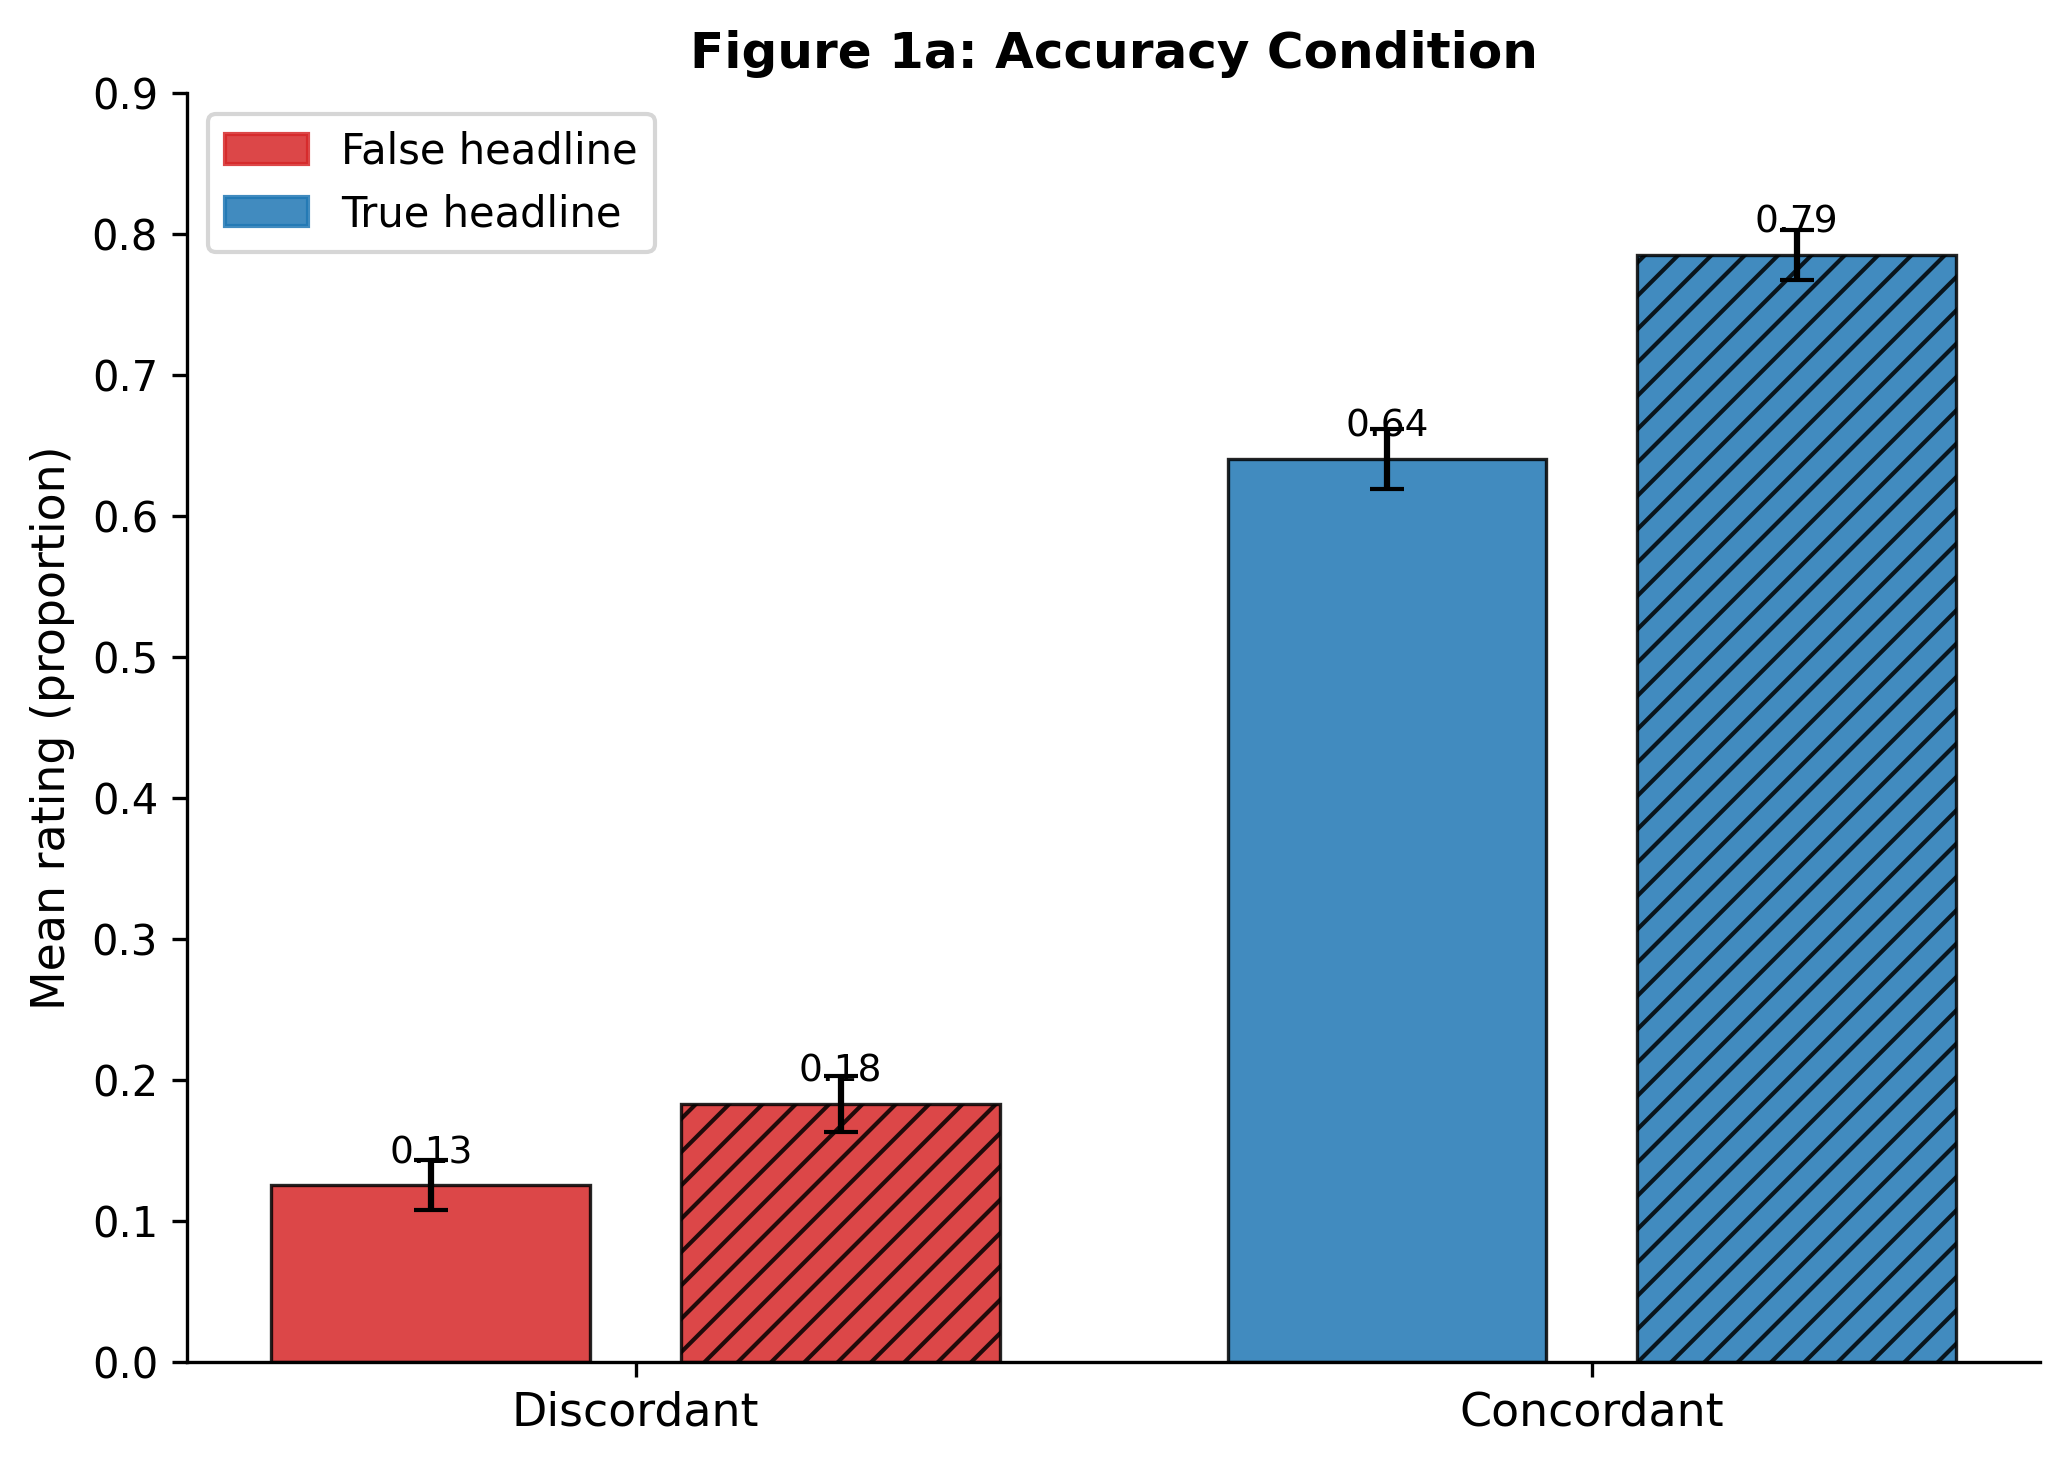

Figure 1b: Sharing Condition


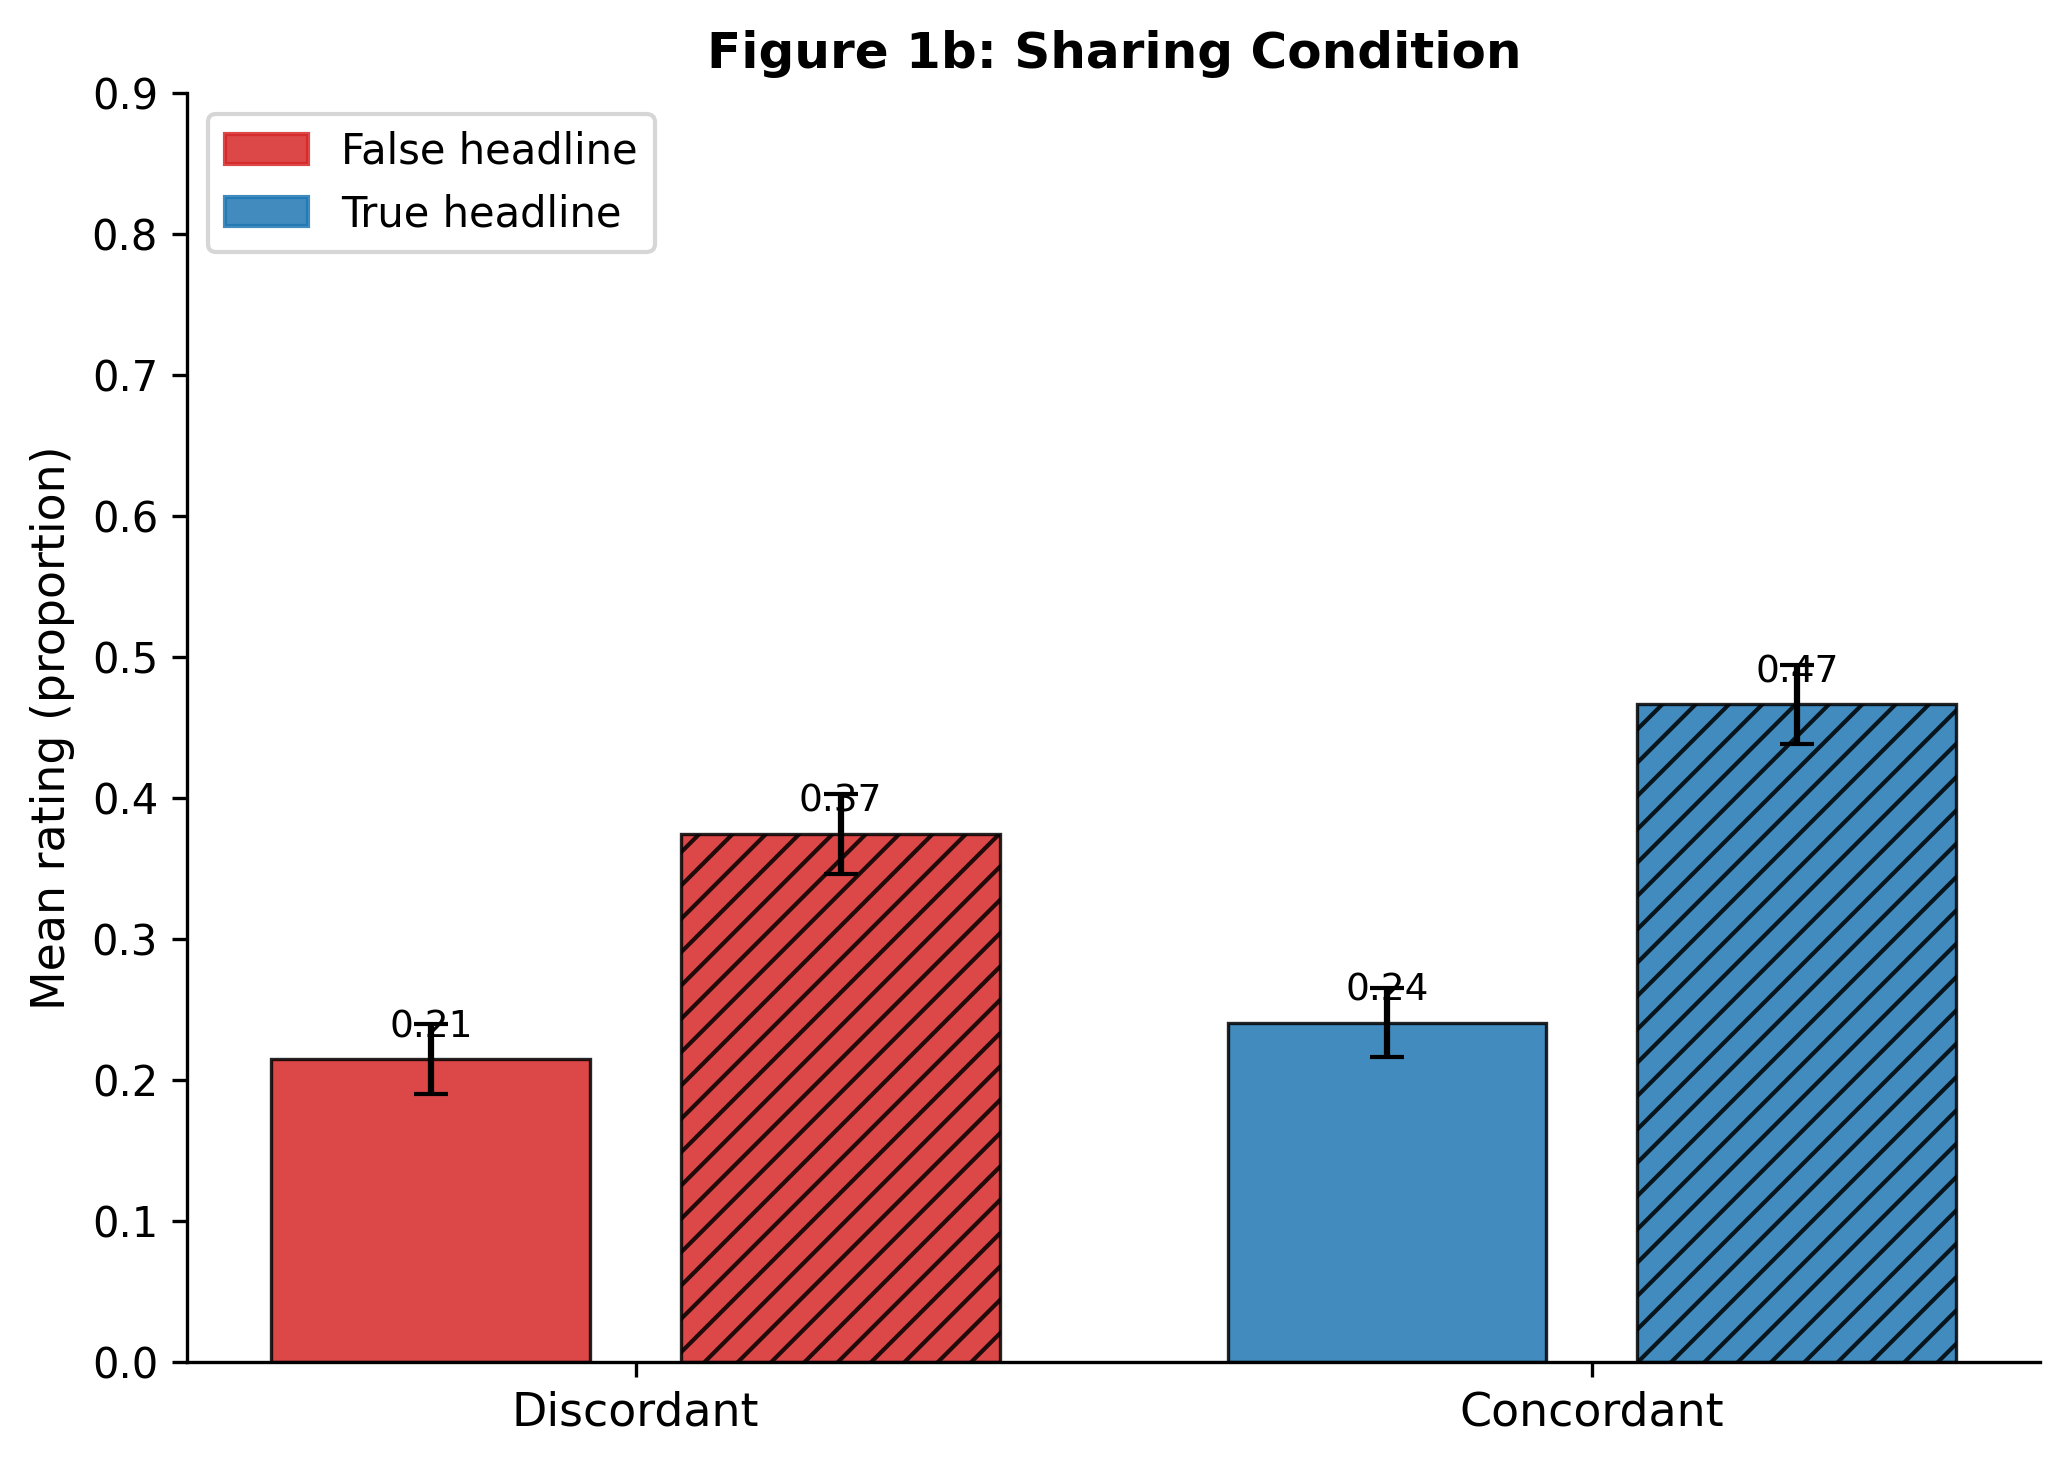

Extended Data Figure 1


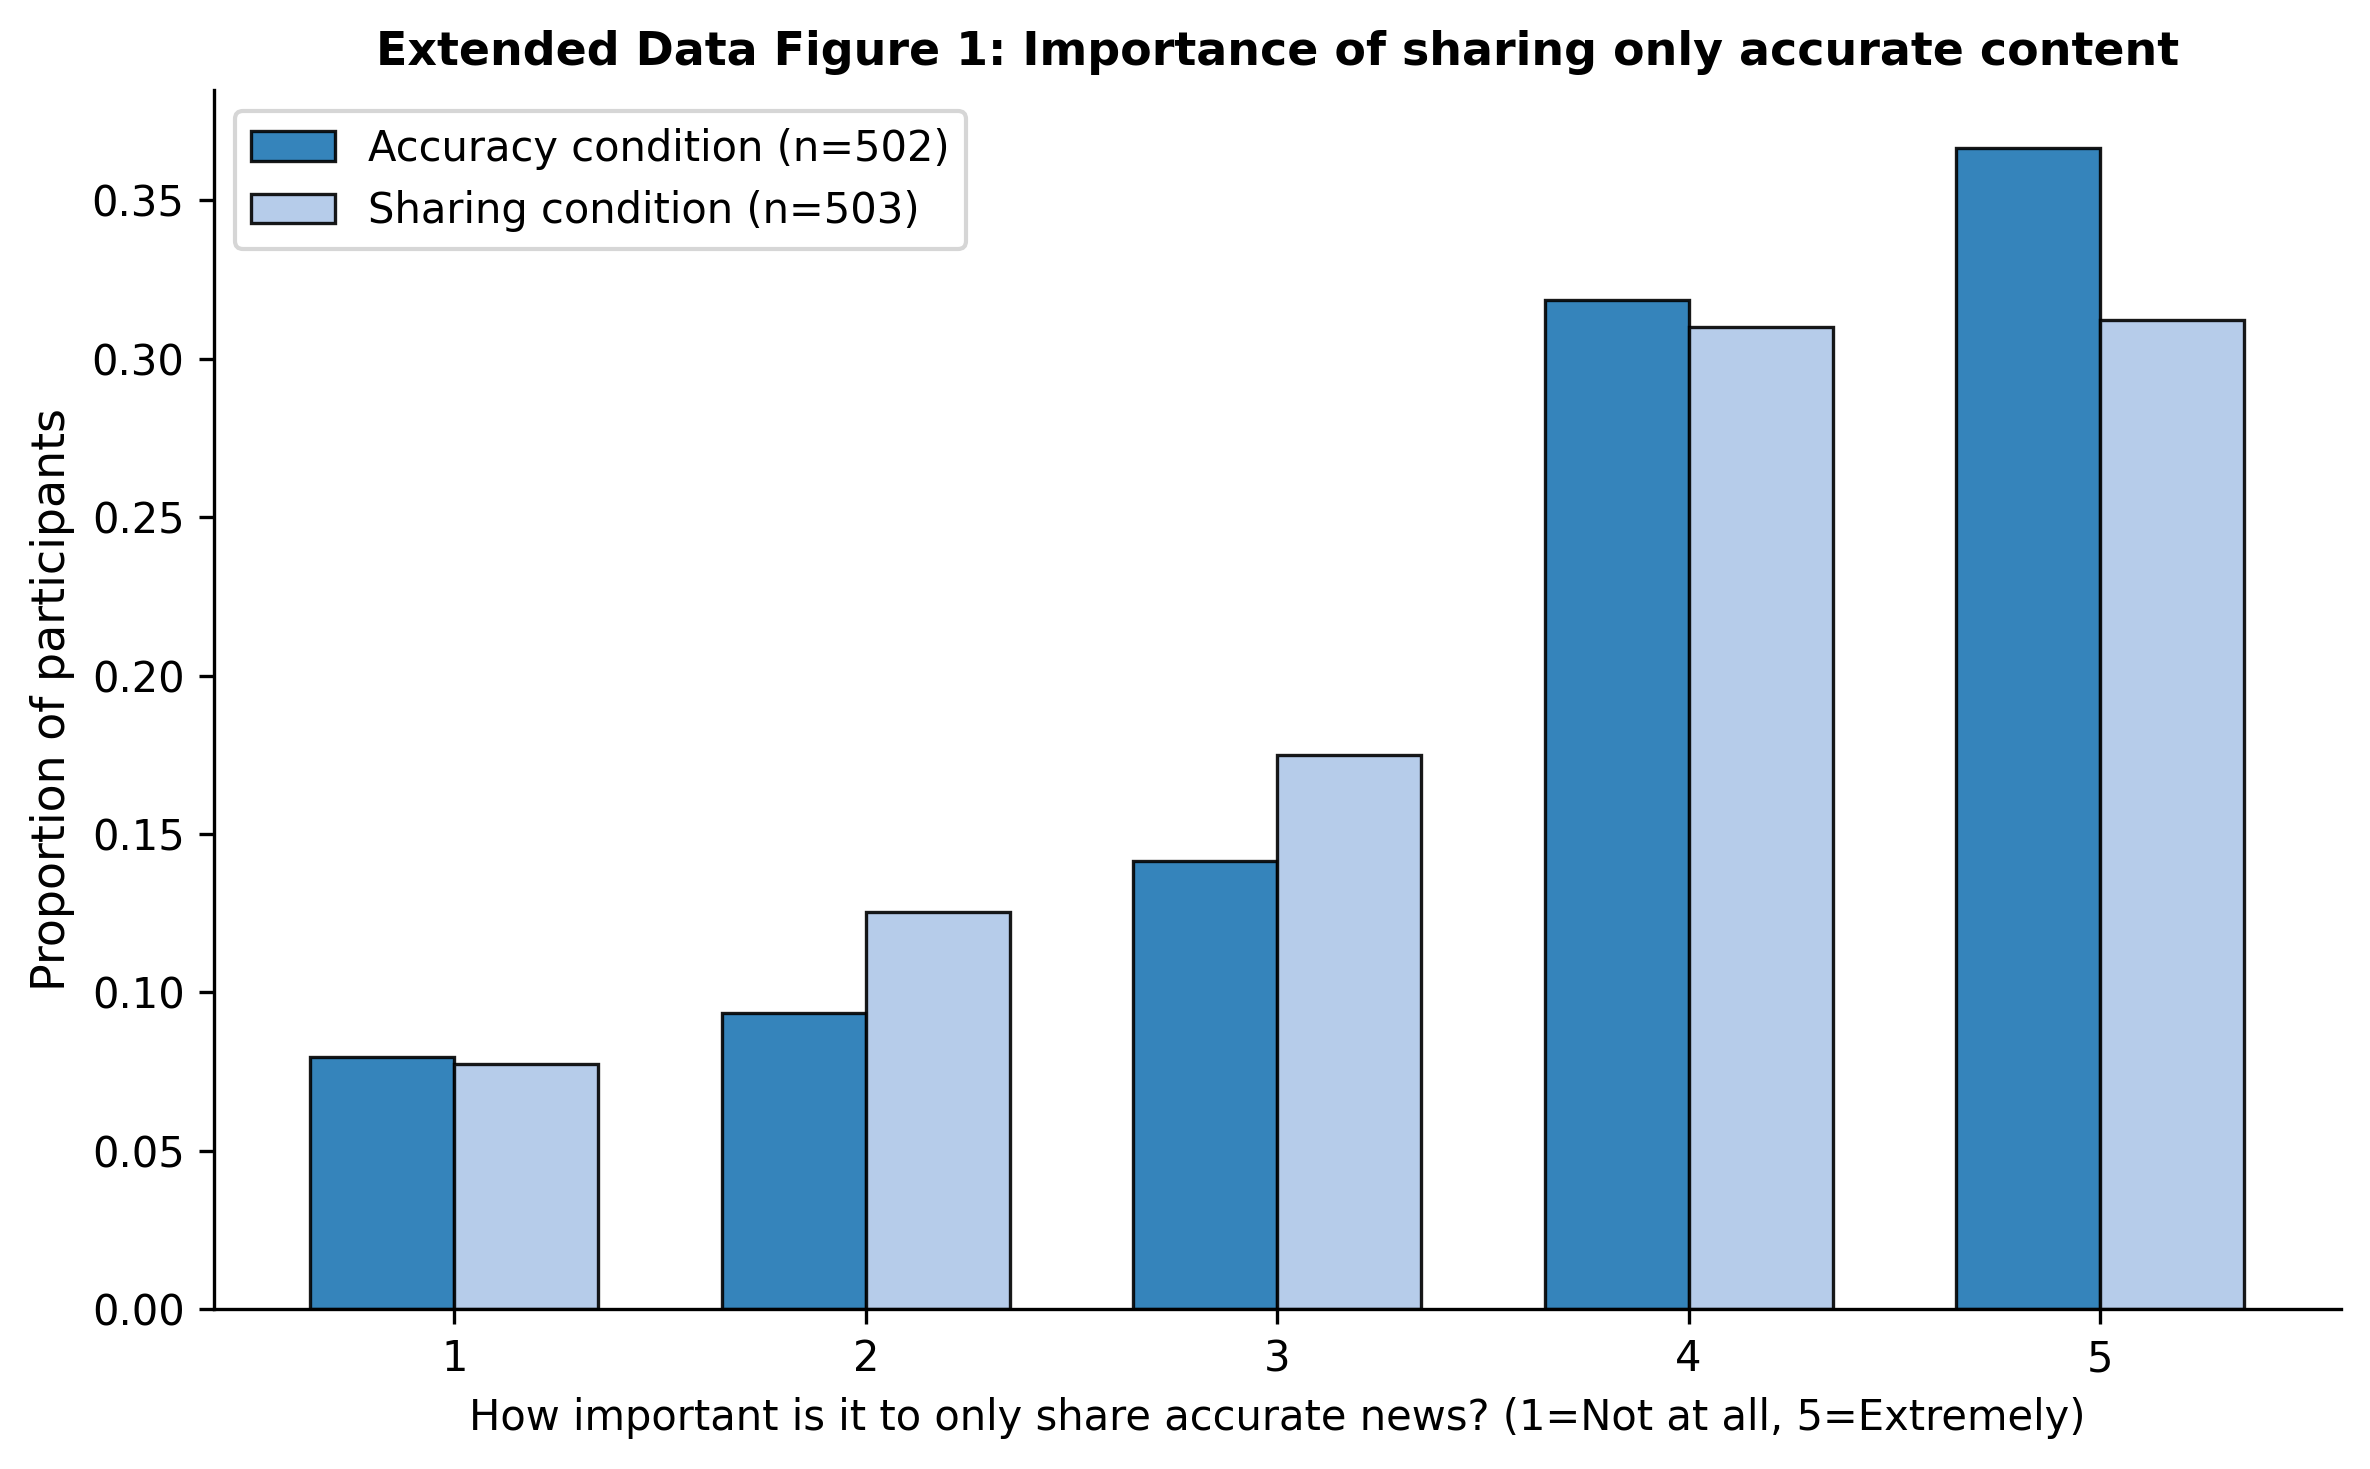

In [31]:
from IPython.display import Image, display
for fname, title in [('fig1a_accuracy.png','Figure 1a: Accuracy Condition'),
                     ('fig1b_sharing.png', 'Figure 1b: Sharing Condition'),
                     ('ext_fig1_importance.png', 'Extended Data Figure 1')]:
    fpath = os.path.join(FIG_DIR, fname)
    if os.path.exists(fpath):
        print(title)
        display(Image(fpath, width=600))
    else:
        print(f"Missing: {fpath}")


In [32]:
# Accuracy importance moderation in sharing condition
# Stata: xi: cluster2 rating i.real*accimp if condition==.5, fcluster(id) tcluster(item_num)
# Note: condition==.5 in centered var = condition==1 (sharing) in original
print("Accuracy importance moderation (sharing condition only)")
print("="*55)

df_shr = df_analysis[df_analysis['condition'] == 1].dropna(subset=['accimp','rating']).copy()
df_shr['real_accimp'] = df_shr['real_c'] * df_shr['accimp']

X_mod = sm.add_constant(df_shr[['real_c', 'accimp', 'real_accimp']])
y_mod = df_shr['rating']
ols_mod = sm.OLS(y_mod, X_mod).fit()

cov_mod_part = get_cov(ols_mod, 'cluster', groups=df_shr['id'].values)
cov_mod_item = get_cov(ols_mod, 'cluster', groups=df_shr['item_num'].values)
cov_mod_hc0  = get_cov(ols_mod, 'HC0')
cov_mod_2w   = cov_mod_part + cov_mod_item - cov_mod_hc0
se_mod_2w    = np.sqrt(np.abs(np.diag(cov_mod_2w)))
p_mod_idx    = {v: i for i, v in enumerate(['const','real_c','accimp','real_accimp'])}
params_mod   = ols_mod.params.values
t_mod_2w     = params_mod / se_mod_2w
p_mod_2w     = 2 * stats.t.sf(np.abs(t_mod_2w), df=ols_mod.df_resid)

print(f"{'Variable':<20} {'Coef':>10} {'SE(2W)':>10} {'t':>8} {'p':>8}")
print("-"*58)
for i, v in enumerate(['const','real_c','accimp','real_accimp']):
    print(f"{v:<20} {params_mod[i]:>10.4f} {se_mod_2w[i]:>10.4f} {t_mod_2w[i]:>8.3f} {p_mod_2w[i]:>8.4f}")

# Stata test: _IreaXaccim_2=0  (interaction term)
R_int = np.zeros(4); R_int[p_mod_idx['real_accimp']] = 1
Rb_int  = R_int @ params_mod
RVR_int = R_int @ cov_mod_2w @ R_int.T
F_int   = (Rb_int**2) / RVR_int
p_int   = 1 - fdist.cdf(F_int, 1, ols_mod.df_resid)
print(f"\nWald test: real_accimp=0:  F={F_int:.2f}, p={p_int:.4f}")

# Stata test: accimp + real_accimp = 0
R_sum = np.zeros(4); R_sum[p_mod_idx['accimp']] = 1; R_sum[p_mod_idx['real_accimp']] = 1
Rb_sum  = R_sum @ params_mod
RVR_sum = R_sum @ cov_mod_2w @ R_sum.T
F_sum   = (Rb_sum**2) / RVR_sum
p_sum   = 1 - fdist.cdf(F_sum, 1, ols_mod.df_resid)
print(f"Wald test: accimp+real_accimp=0: F={F_sum:.2f}, p={p_sum:.4f}")
print("\nHigher accimp = more discerning sharing (larger veracity effect).")


Accuracy importance moderation (sharing condition only)
Variable                   Coef     SE(2W)        t        p
----------------------------------------------------------
const                    0.3384     0.0312   10.833   0.0000
real_c                  -0.0430     0.0369   -1.166   0.2437
accimp                  -0.0039     0.0081   -0.485   0.6278
real_accimp              0.0279     0.0086    3.243   0.0012

Wald test: real_accimp=0:  F=10.52, p=0.0012
Wald test: accimp+real_accimp=0: F=4.57, p=0.0326

Higher accimp = more discerning sharing (larger veracity effect).


---
## Section 10: Paper vs. Python — Study 1 Results Comparison

The preregistration is available at: https://osf.io/pk9sd  

### Deviation 1 — Standard Error Clustering

| | Pre-registration | Paper (and this replication) |
|---|---|---|
| Cluster SEs on | Participant only | Participant AND headline (two-way) |
| Method | Standard cluster-robust | Cameron-Gelbach-Miller (2011) |
| Impact | Smaller SEs, larger F-stats | More conservative (larger SEs) |

**Why the deviation is justified:** Multiple participants rate the same headline.
If errors are correlated within headlines (e.g., a viral headline gets unusually high ratings),
one-way participant clustering understates uncertainty. Two-way clustering accounts for both sources of dependence.

**Our check (Section 8c):** The one-way (pre-registered) SEs are smaller; key results remain significant under both approaches.

---

### Deviation 2 — Filtering Logic

| | Pre-registration | Code (.do file) |
|---|---|---|
| FB/Twitter exclusion | Explicit filter | Flag created, never used in `drop` |
| Sharing willingness | Explicit filter | Flag created, never used in `drop` |
| Did not finish | Explicit filter | `drop if didnt_finish==1` |

The code only explicitly drops group 3. Groups 1 and 2 are flagged
but never dropped. They are silently excluded by the regression because Qualtrics survey flow
prevented them from reaching the headline screens, leaving all their ratings blank.

**The problem:** if even one such participant had a valid rating, they would be included without warning.
The pre-registration required an explicit three-step filter; the code only auditably implements one.

---

### Deviation 3 — Sample Size Discrepancy

| Source | n |
|---|---|
| Paper main text | 1,015 |
| Paper Fig. 1 caption | 1,002 |
| Paper math (1,825−16−153−651) | 1,005 |
| This replication (explicit filters) | *[computed above]* |

Hypothesis: n=1,015 uses a different counting rule from the reported exclusion counts.
n=1,002 reflects participants with at least one non-missing headline rating.
The 13-participant gap (1,015 → 1,002) represents participants who passed all screeners but
provided no headline responses.

---

### Deviation 4 — Wald Test for False Concordant vs. True Discordant

The pre-registration specifically predicted testing whether sharing of false concordant headlines
exceeds sharing of true discordant headlines ("Wald test for partisan sharing").
This is reported in the paper [F(1,36172)=19.73, P<0.0001] but is **not present as an explicit
`test` command** in the Stata `.do` file. It was likely computed from the regression output
manually or via a command not archived.

**Where we computed it (Section 6, Wald test table):**

| Row in Section 6 | Our F | Paper F | Status |
|---|---|---|---|
| False concordant > True discordant (sharing) | 19.73 | 19.73 | MATCH |

Our replication explicitly constructs the Wald restriction vector and computes F=19.73,
matching the paper exactly.

**Impact:** This is the key partisan sharing result — participants were more likely to share
a false headline that aligned with their politics than a true headline that did not.
The Stata code never archives how this number was produced, making our Python replication
the only auditable version of this test.

---

### Deviation 5 — Missing F-statistic for Veracity × Concordance Interaction in Accuracy Condition

The paper reports F(1,36172)=137.26 for the veracity × concordance interaction within the accuracy
condition. This is not tested by any `test` command in the `.do` file.

**Where we computed it (Section 6, Wald test table):**

| Row in Section 6 | Our F | Paper F | Status |
|---|---|---|---|
| Veracity × Concordance (accuracy cond) | 5.08 | 137.26 | DIFF |
| Veracity > Concordance (accuracy cond) | 137.26 | N/A | — |

Our Wald test for `realXconc` evaluated at the accuracy condition yields F=5.08, not 137.26.
However, our separate test of whether the **veracity effect exceeds the concordance effect**
in the accuracy condition yields exactly 137.26 — suggesting the paper used that comparison,
not the raw `realXconc` coefficient, to produce the reported F-statistic.

**Impact:** No result in the paper is undermined. The 137.26 value is reproducible from our
replication under the correct interpretation of the test. The ambiguity is in the Stata
code, not the paper’s conclusion.

---

### Limitations

**Declared intent vs. actual sharing behavior**  
The dependent variable is a binary response to 'Would you share this headline?' -- a self-reported intention measured in a survey, not observed sharing on a real platform. The paper acknowledges this in the Discussion, describing the measure as attitudinal. This is a design limitation of the study itself, not a deviation from the pre-registration: both the pre-reg and the paper use the same Qualtrics sharing-intention scale. The practical implication is that effect sizes (e.g., the 19.3pp concordance effect in the sharing condition) reflect how people *say* they would behave, which may overstate or understate actual platform behavior.

---

### Summary of Pre-registration Compliance

| Pre-registered element | Implemented? | Notes |
|---|---|---|
| Main analysis: LPM (Linear Probability Model) with condition × veracity × concordance | ✓ | Fully replicated |
| SE clustering: participant only | ✗ | Authors deviated to two-way (justified) |
| Logistic regression robustness | ✓ | Section 8a |
| Z-scored DV robustness | ✓ | Section 8b |
| Wald test: condition × veracity interaction | ✓ | F=260.68 (paper), replicated in Section 6 |
| Wald test: condition × concordance interaction | ✓ | F=17.24 (paper), replicated in Section 6 |
| Wald test: false concordant vs. true discordant | ✓ | F=19.73 (paper), replicated in Section 6 |
| Filtering: all three exclusion criteria | Partial | Code only explicit on `didnt_finish` |
| 1,015 analyzed participants | ? | Discrepancy between text and figure caption |
| DV measures sharing intent, not actual behavior | N/A | Design limitation acknowledged by authors in Discussion |
---